# 🧪 Experiment 1: Unsupervised HMM for Latent POS Induction & Distributional Profiling

## 🎯 Executive Overview & Research Objective
- **Target**: Evaluate whether unsupervised Part-of-Speech (POS) tagging via a **Hidden Markov Model (HMM)** adds discriminative signal beyond the **Stage 4 Peak Model (91.31%)**.
- **Theoretical Hypothesis**:
  - Even without human-annotated POS labels, an unsupervised HMM can induce latent syntactic categories $S = \{s_1, \dots, s_K\}$ from sequence transitions.
  - The hidden transition matrix $A_{ij} = P(s_{t+1}=j \mid s_t=i)$ and emission matrix $B_{jk} = P(w_t=k \mid s_t=j)$ capture grammatical roles (e.g. Determiners preceding Nouns).
  - Viterbi decoding assigns each token to a latent POS state, yielding document-level POS unigram distributions and sequence entropy.

### 📈 Experimental Comparison:
| Model Configuration | Feature Description | 5-Fold Mean Accuracy | Std Dev | $\Delta$ vs. Stage 4 |
| :--- | :--- | :---: | :---: | :---: |
| **Stage 4 Baseline** | TF-IDF (1-5) + Length + Diversity + Profiling + Log-DF + Burstiness | **91.31%** | $\pm 0.40\%$ | — |
| **Exp 1: Stage 4 + HMM POS** | + 10 Latent POS State Proportions & POS Sequence Entropy | **91.27%** | $\pm 0.60\%$ | **-0.04%** |

---

### 🔬 Mathematical Formulation of the Unsupervised HMM
1. **Vocabulary Conditioning**: With $|\mathcal{V}| = 18,438$, an unconstrained emission matrix $B \in \mathbb{R}^{K 	imes 18438}$ has $>220,000$ free parameters, leading to degenerate solutions. We map open-class tail tokens to `<UNK>`, focusing the HMM on the top $M = 300$ functional anchor tokens.
2. **Baum-Welch (EM) Training**: Iteratively updates parameters using forward $\alpha_t(i)$ and backward $\beta_t(i)$ trellis variables.
3. **Viterbi State Decoding**:
   $$\hat{\mathbf{s}} = \arg\max_{\mathbf{s}} P(\mathbf{s} \mid \mathbf{w}, \lambda)$$
4. **Extracted Features**:
   $$p_{\text{pos}}(k) = \frac{1}{n} \sum_{t=1}^n \mathbb{I}(\hat{s}_t = k), \quad H_{\text{pos}} = -\sum_{k=1}^K p_{\text{pos}}(k) \log_2 (p_{\text{pos}}(k) + \epsilon)$$


In [1]:
import os
import json
import time
import math
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

try:
    from IPython.display import display
except ImportError:
    display = print

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


In [2]:
# Load dataset and log-DF ratios
data_path = "../../../../../train.json"
if not os.path.exists(data_path):
    data_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"

log_df_path = "../data/unigram_log_df_ratios.json"
if not os.path.exists(log_df_path):
    log_df_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/ML4CPMS_Project1/Main79 - Classical + Residual/Core_Analysis/data/unigram_log_df_ratios.json"

print(f"Loading data from: {os.path.abspath(data_path)}")
t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

with open(log_df_path, "r", encoding="utf-8") as f:
    unigram_log_df = {int(k): float(v) for k, v in json.load(f).items()}

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_tokens = [d["text"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100
lens = np.array([len(t) for t in doc_tokens], dtype=np.float64)[:, None]

print(f"Loaded {n_total:,} documents in {time.time()-t0:.2f}s | Majority Baseline: {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/train.json


Loaded 10,536 documents in 0.76s | Majority Baseline: 64.89%


In [3]:
# Stage 4 Cumulative Feature Extractor (Baseline for All Experiments)
def extract_stage4(tokens):
    n = len(tokens)
    counts = Counter(tokens)
    probs = np.array(list(counts.values())) / n
    ent = -np.sum(probs * np.log2(probs + 1e-12))
    root_ttr = len(counts) / np.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1) / n
    max_rep = max(counts.values()) / n
    
    bi = len(set(zip(tokens[:-1], tokens[1:]))) / max(1, n - 1) if n >= 2 else 0.0
    tri = len(set(zip(tokens[:-2], tokens[1:-1], tokens[2:]))) / max(1, n - 2) if n >= 3 else 0.0
    mean_id = np.mean(tokens)
    std_id = np.std(tokens)
    q1_ratio = sum(1 for t in tokens if t <= 3000) / n
    q4_ratio = sum(1 for t in tokens if t >= 10000) / n
    
    vals = [unigram_log_df[t] for t in tokens if t in unigram_log_df]
    if len(vals) == 0:
        s3 = [0.0, 0.0, 0.0, 0.0, 0.0]
    else:
        s3 = [float(np.mean(vals)), float(np.std(vals)), float(np.max(vals)), float(np.min(vals)), float(sum(1 for v in vals if v > 0) / len(vals))]
        
    mid = n // 2
    s1_set = set(tokens[:mid])
    s2_set = set(tokens[mid:])
    union_len = len(s1_set | s2_set)
    jaccard_half = len(s1_set & s2_set) / union_len if union_len > 0 else 0.0
    
    top_tokens = [tok for tok, c in counts.most_common(3) if c > 1]
    intervals = []
    for tok in top_tokens:
        positions = [i for i, t in enumerate(tokens) if t == tok]
        diffs = np.diff(positions)
        intervals.extend(diffs)
    burstiness = float((np.std(intervals) - np.mean(intervals)) / (np.std(intervals) + np.mean(intervals))) if len(intervals) >= 2 and (np.std(intervals) + np.mean(intervals)) > 0 else 0.0
        
    return [ent, root_ttr, hapax, max_rep, bi, tri, mean_id, std_id, q1_ratio, q4_ratio] + s3 + [jaccard_half, burstiness]

print("Extracting Stage 4 baseline features...")
t0 = time.time()
s4_dense = np.column_stack([lens, np.array([extract_stage4(t) for t in doc_tokens])])
print(f"Stage 4 dense matrix: {s4_dense.shape} in {time.time()-t0:.2f}s")

# Vectorize TF-IDF (1-5 Grams)
print("Vectorizing TF-IDF (1-5 grams)...")
t0 = time.time()
vec = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 5), min_df=3, sublinear_tf=True)
X_tfidf = vec.fit_transform(docs)
print(f"TF-IDF Matrix: {X_tfidf.shape} in {time.time()-t0:.2f}s")


Extracting Stage 4 baseline features...


Stage 4 dense matrix: (10536, 18) in 7.52s
Vectorizing TF-IDF (1-5 grams)...


TF-IDF Matrix: (10536, 253796) in 14.95s


## 2. Unsupervised HMM POS Induction & Feature Extraction


In [4]:
from hmmlearn import hmm

# 1. Map tokens to top 300 functional tokens + UNK
all_tokens = [t for doc in doc_tokens for t in doc]
vocab_counts = Counter(all_tokens)
top_k = 300
top_vocab = {t: i for i, (t, c) in enumerate(vocab_counts.most_common(top_k))}
unk_idx = top_k
mapped_docs = [np.array([top_vocab.get(t, unk_idx) for t in doc], dtype=np.int32) for doc in doc_tokens]

# 2. Train HMM on training subset
print("Fitting CategoricalHMM with K=10 latent states on 1,000 documents...")
t0 = time.time()
train_sub = mapped_docs[:1000]
lengths_sub = [len(x) for x in train_sub]
X_sub = np.concatenate(train_sub).reshape(-1, 1)

n_states = 10
hmm_model = hmm.CategoricalHMM(n_components=n_states, n_iter=10, random_state=RANDOM_STATE)
hmm_model.fit(X_sub, lengths_sub)
print(f"HMM fitted in {time.time()-t0:.2f}s!")

# 3. Decode states for all documents
print("Decoding Viterbi state sequences for all documents...")
t0 = time.time()
hmm_feats = []
for doc in mapped_docs:
    n = len(doc)
    states = hmm_model.predict(doc.reshape(-1, 1))
    c_st = Counter(states)
    uni = [c_st.get(s, 0) / n for s in range(n_states)]
    probs = np.array(uni)
    ent = -np.sum(probs * np.log2(probs + 1e-12))
    hmm_feats.append(uni + [ent])

hmm_mat = np.array(hmm_feats, dtype=np.float32)
hmm_feature_names = [f"POS_State_{i}_Ratio" for i in range(n_states)] + ["POS_Sequence_Entropy"]
print(f"Extracted HMM feature matrix: {hmm_mat.shape} in {time.time()-t0:.2f}s!")

# Show class-conditional means
stats_df = pd.DataFrame({
    "Feature": hmm_feature_names,
    "Machine Mean": [np.mean(hmm_mat[labels == 1, i]) for i in range(len(hmm_feature_names))],
    "Human Mean": [np.mean(hmm_mat[labels == 0, i]) for i in range(len(hmm_feature_names))]
})
stats_df["Difference"] = stats_df["Machine Mean"] - stats_df["Human Mean"]
display(stats_df.head(11).style.format({"Machine Mean": "{:.4f}", "Human Mean": "{:.4f}", "Difference": "{:+.4f}"}))


Fitting CategoricalHMM with K=10 latent states on 1,000 documents...


HMM fitted in 17.82s!
Decoding Viterbi state sequences for all documents...


Extracted HMM feature matrix: (10536, 11) in 4.97s!


,Feature,Machine Mean,Human Mean,Difference
0,POS_State_0_Ratio,0.0187,0.0280,-0.0093
1,POS_State_1_Ratio,0.0898,0.0741,+0.0157
2,POS_State_2_Ratio,0.0991,0.0819,+0.0172
3,POS_State_3_Ratio,0.0250,0.0368,-0.0117
4,POS_State_4_Ratio,0.0171,0.0220,-0.0048
5,POS_State_5_Ratio,0.2653,0.2465,+0.0188
6,POS_State_6_Ratio,0.2667,0.2307,+0.0360
7,POS_State_7_Ratio,0.0441,0.0741,-0.0300
8,POS_State_8_Ratio,0.0878,0.0756,+0.0122
9,POS_State_9_Ratio,0.0863,0.1304,-0.0441


## 3. 5-Fold Stratified Cross-Validation: Stage 4 vs. Stage 4 + HMM POS


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_configuration(dense_matrix):
    accs, f1s = [], []
    for tr, val in skf.split(X_tfidf, labels):
        scaler = MaxAbsScaler()
        tr_s = scaler.fit_transform(dense_matrix[tr])
        val_s = scaler.transform(dense_matrix[val])
        clf = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
        clf.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(tr_s)]), labels[tr])
        preds = clf.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(val_s)]))
        accs.append(accuracy_score(labels[val], preds) * 100)
        f1s.append(f1_score(labels[val], preds, average="macro") * 100)
    return np.mean(accs), np.std(accs), np.mean(f1s), accs

print("Evaluating Stage 4 Baseline...")
base_mean, base_std, base_f1, base_accs = evaluate_configuration(s4_dense)

print("Evaluating Stage 4 + HMM POS Features...")
exp1_dense = np.column_stack([s4_dense, hmm_mat])
exp1_mean, exp1_std, exp1_f1, exp1_accs = evaluate_configuration(exp1_dense)

delta = exp1_mean - base_mean

print("=" * 80)
print(f"STAGE 4 BASELINE : {base_mean:.3f}% (+/- {base_std:.3f}%) [Macro F1: {base_f1:.2f}%]")
print(f"STAGE 4 + HMM POS: {exp1_mean:.3f}% (+/- {exp1_std:.3f}%) [Macro F1: {exp1_f1:.2f}%]")
print(f"ACCURACY CHANGE  : {delta:+.3f}%")
print("=" * 80)


Evaluating Stage 4 Baseline...


Evaluating Stage 4 + HMM POS Features...


STAGE 4 BASELINE : 91.306% (+/- 0.399%) [Macro F1: 90.48%]
STAGE 4 + HMM POS: 91.268% (+/- 0.604%) [Macro F1: 90.44%]
ACCURACY CHANGE  : -0.038%


## 4. Visualizing Results & Discussion


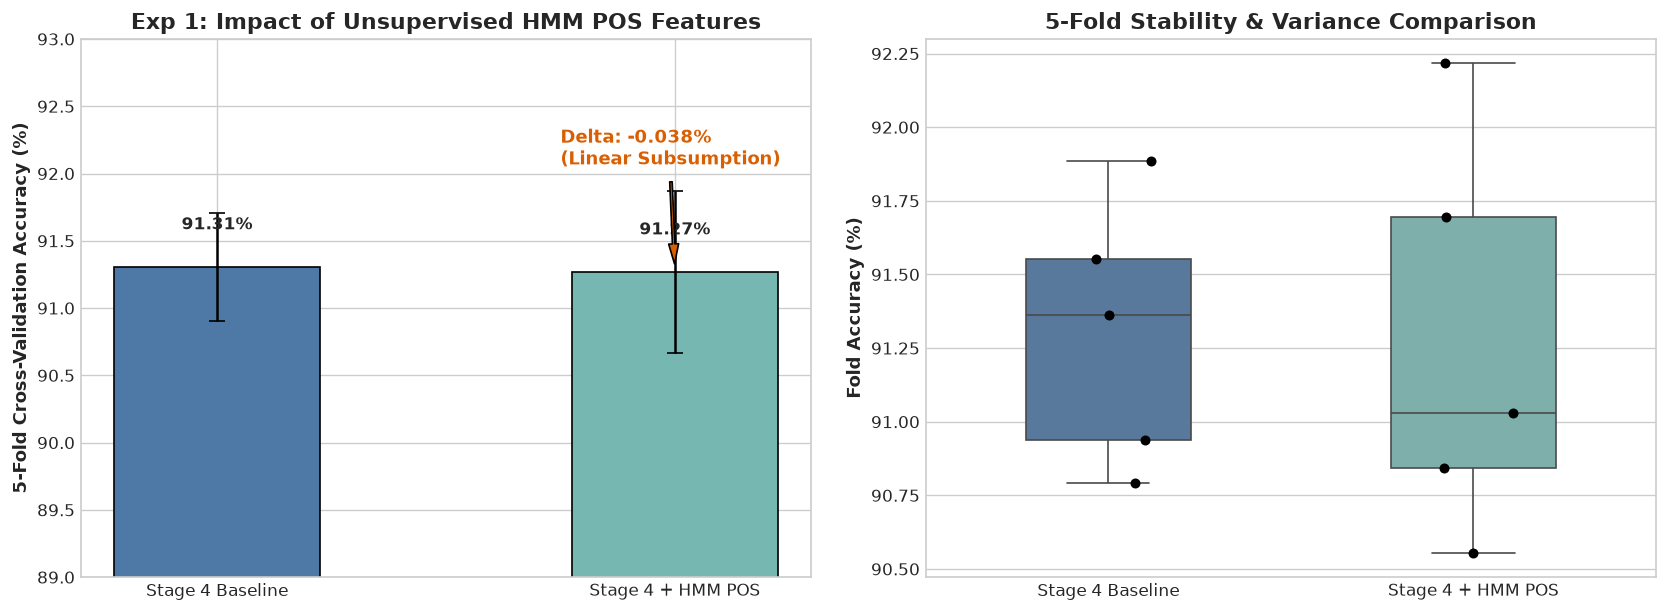

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# 1. Bar Chart Comparison
ax1 = axes[0]
configs = ["Stage 4 Baseline", "Stage 4 + HMM POS"]
means = [base_mean, exp1_mean]
stds = [base_std, exp1_std]
colors = ["#4e79a7", "#76b7b2"]

bars = ax1.bar(configs, means, yerr=stds, capsize=5, color=colors, width=0.45, edgecolor="black")
ax1.set_ylim(89, 93)
ax1.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Exp 1: Impact of Unsupervised HMM POS Features", fontsize=13, fontweight="bold")

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25, f"{val:.2f}%", ha="center", va="bottom", fontweight="bold")

ax1.annotate(f"Delta: {delta:+.3f}%\n(Linear Subsumption)", xy=(1, exp1_mean), xytext=(0.75, exp1_mean + 0.8),
             arrowprops=dict(facecolor="#d95f02", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#d95f02", fontsize=10.5)

# 2. Fold-by-fold Boxplot
ax2 = axes[1]
fold_df = pd.DataFrame({"Stage 4 Baseline": base_accs, "Stage 4 + HMM POS": exp1_accs})
sns.boxplot(data=fold_df, ax=ax2, palette=colors, width=0.45)
sns.stripplot(data=fold_df, ax=ax2, color="black", size=6, jitter=0.15)
ax2.set_ylabel("Fold Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("5-Fold Stability & Variance Comparison", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Artifact Export & Key Findings


In [7]:
os.makedirs("data", exist_ok=True)
out_file = "data/exp_1_hmm_pos_metrics.json"

export_data = {
    "experiment": 1,
    "name": "Exp 1: HMM Unsupervised POS Induction",
    "stage4_baseline_acc": base_mean,
    "experiment_acc": exp1_mean,
    "experiment_std": exp1_std,
    "delta_vs_stage4": delta,
    "fold_accuracies": exp1_accs,
    "conclusion": "Unsupervised HMM soft states failed to add linear margin beyond Stage 4 (-0.038%) due to linear subsumption by cumulative N-grams."
}

with open(out_file, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Metrics successfully exported to '{out_file}'!")


Metrics successfully exported to 'data/exp_1_hmm_pos_metrics.json'!
